<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H5 - Demand and Search Interest Analysis

## Objective

- The objective of this notebook is to analyze whether Google search interest for dates has a significant relationship with estimated date demand in Saudi Arabia.

## Hypothesis

- H₀: Search interest does not have a significant relationship with estimated date demand.

- H₁: Search interest has a significant relationship with estimated date demand.

## 1) Uploading Datasets

- Upload production, trade balance, and search interest datasets for analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving production (2).csv to production (2).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving balance.csv to balance.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving search.csv to search.csv


## 2) Creating Estimated Demand

- This part uses production, imports, and exports to estimate yearly date demand.

In [ ]:
import pandas as pd

# Load production and trade balance datasets
production = pd.read_csv("production (2).csv")
balance = pd.read_csv("balance.csv")

# Keep only production rows
prod = production[production["Element"] == "Production"][["Year", "Value"]].copy()
prod = prod.rename(columns={"Value": "Production"})

# Keep trade balance columns
trade = balance[["Year", "Element", "Value"]].copy()

# Convert trade data into separate import and export columns
trade_pivot = trade.pivot_table(
    index="Year",
    columns="Element",
    values="Value",
    aggfunc="sum"
).reset_index()

# Rename import and export columns
trade_pivot = trade_pivot.rename(columns={
    "Import Quantity": "Imports",
    "Export Quantity": "Exports",
    "Import quantity": "Imports",
    "Export quantity": "Exports"
})

# Merge production and trade data
df = pd.merge(prod, trade_pivot, on="Year", how="inner")

# Calculate estimated demand
df["Demand"] = df["Production"] + df["Imports"] - df["Exports"]

# Keep only year and demand
demand_df = df[["Year", "Demand"]].copy()

demand_df.head()

,Year,Demand
0,2000,706705.17
1,2001,786092.00
2,2002,796348.00
3,2003,851191.00
4,2004,896572.00


## 3) Preparing Search Interest Data

- This part converts monthly Google Trends search interest into yearly average search interest.

In [ ]:
import pandas as pd

trends = pd.read_csv("search.csv")

search = pd.read_csv("search.csv")
search = search.rename(columns={"تمر": "Dates"})

# Convert time column to datetime format
search["Time"] = pd.to_datetime(search["Time"])

# Extract year from date
search["Year"] = search["Time"].dt.year

# Calculate yearly average search interest
search_yearly = search.groupby("Year", as_index=False)["Dates"].mean()

# Rename search interest column
search_yearly = search_yearly.rename(columns={"Dates": "Search_Interest"})
search_yearly.head()

,Year,Search_Interest
0,2004,1.916667
1,2005,3.833333
2,2006,9.250000
3,2007,13.583333
4,2008,13.083333


## 4) Merging Demand and Search Data

- This part merges estimated demand with yearly search interest by year.

In [ ]:
final_df = pd.merge(demand_df, search_yearly, on="Year", how="inner")

# Remove missing values
final_df = final_df.dropna()
final_df.head()


,Year,Demand,Search_Interest
0,2004,896572.0,1.916667
1,2005,922178.0,3.833333
2,2006,935214.0,9.250000
3,2007,935352.0,13.583333
4,2008,932164.0,13.083333


## 5) Pearson Correlation Test

- This part tests whether search interest and estimated demand have a significant linear relationship.

In [ ]:
from scipy.stats import pearsonr

# Calculate Pearson correlation between search interest and demand
r, p = pearsonr(final_df["Search_Interest"], final_df["Demand"])

print("Correlation (r):", r)
print("P-value:", p)

Correlation (r): 0.8328373655631637
P-value: 2.7993248648320913e-06


## Results

- The Pearson correlation value is 0.833, showing a strong positive relationship between search interest and estimated demand.

- The p-value is 0.0000028, which is less than 0.05.

- Since the p-value is below 0.05, we reject the null hypothesis (H₀).

- This means there is enough statistical evidence to conclude that search interest has a significant relationship with estimated date demand.

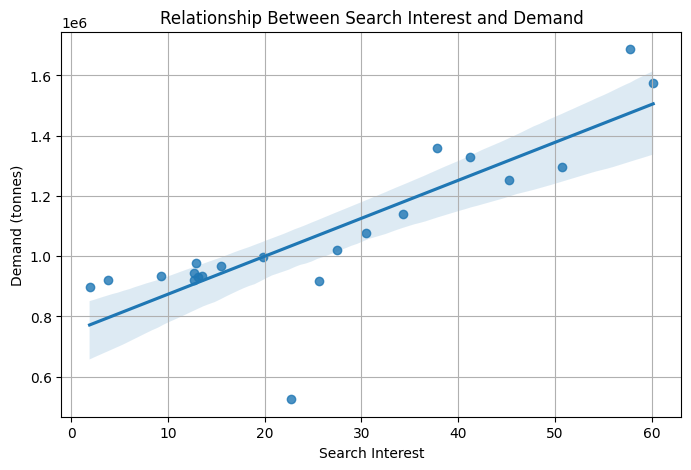

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Create regression plot
sns.regplot(
    x="Search_Interest",
    y="Demand",
    data=final_df
)

plt.xlabel("Search Interest")
plt.ylabel("Demand (tonnes)")
plt.title("Relationship Between Search Interest and Demand")

plt.grid(True)
plt.show()

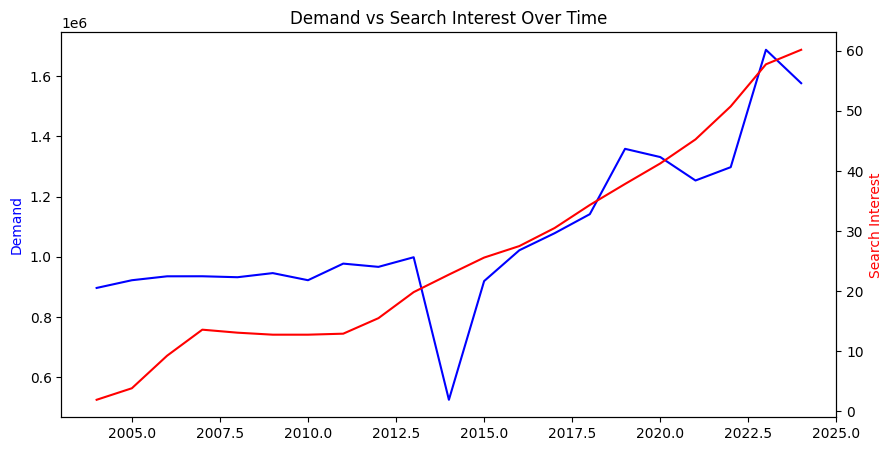

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Plot demand on the first axis
ax1.plot(final_df["Year"], final_df["Demand"], color="blue")
ax1.set_ylabel("Demand", color="blue")

# Plot search interest on the second axis
ax2 = ax1.twinx()
ax2.plot(final_df["Year"], final_df["Search_Interest"], color="red")
ax2.set_ylabel("Search Interest", color="red")

plt.title("Demand vs Search Interest Over Time")
plt.show()

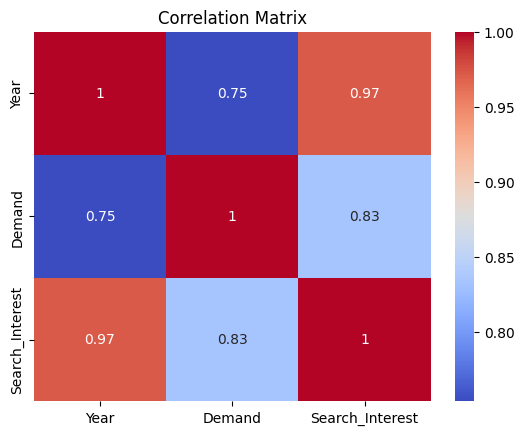

In [ ]:
# Create correlation heatmap
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()